# Product Sales Analysis

This notebook analyzes product sales performance for the Italian Restaurant Analytics project during the period from January to March 2026.

The objective is to identify the strongest and weakest products, evaluate sales concentration, compare quantity sold with revenue performance, and detect products that may require further commercial review.

## Analysis Scope

- Product sales summary
- Top products by sales
- Pareto analysis
- Product sales treemap
- Quantity vs sales relationship
- Top products by quantity sold
- Average sales value per unit
- Lowest-performing products
- Key business insights

In [1]:
# Import the libraries required for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Import the library required to create the treemap

import squarify

In [2]:
# Load the cleaned products dataset and display the first five rows

df = pd.read_excel("../data/cleaned/products_cleaned.xlsx")
df.head()

,Category,Product,Quantity,Quantity (%),Sales,Sales (%)
0,Pasta,Chicken Parmegiana,426.5,0.528218,6467.60,2.045481
1,Pasta,Lasagna,470.0,0.582093,6465.16,2.044709
2,Pasta,Carbonara,492.0,0.609340,6334.68,2.003443
3,Pasta,Ravioli Di Ricotta/Esp,424.3,0.525493,5096.16,1.611741
4,Pasta,Grilled Steak,355.0,0.439666,4819.62,1.524281


In [3]:
# Inspect the product sales dataset structure, size, and data types

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (343, 6)

Column names:
['Category', 'Product', 'Quantity', 'Quantity (%)', 'Sales', 'Sales (%)']

Data types:
Category         object
Product          object
Quantity        float64
Quantity (%)    float64
Sales           float64
Sales (%)       float64
dtype: object


## Product Sales Summary

This section provides a general overview of product sales performance during the January–March 2026 period, including total quantity sold, total sales, average sales per product, and the number of unique products analyzed.

In [4]:
# Calculate key summary metrics for product sales performance

total_quantity = df["Quantity"].sum()
total_sales = df["Sales"].sum()
average_sales_per_product = df["Sales"].mean()
product_count = df["Product"].nunique()

print(f"Total quantity sold: {total_quantity:,.2f}")
print(f"Total sales: ${total_sales:,.2f}")
print(f"Average sales per product: ${average_sales_per_product:,.2f}")
print(f"Unique products analyzed: {product_count}")

Total quantity sold: 42,704.57
Total sales: $307,367.07
Average sales per product: $896.11
Unique products analyzed: 342


## Top Products by Sales

This section identifies the products that generated the highest total sales during the January–March 2026 period, helping determine which items contributed the most revenue.

In [5]:
# Aggregate sales by product and rank from highest to lowest

product_sales = (
    df.groupby("Product", as_index=False)
    .agg({
        "Sales": "sum",
        "Quantity": "sum"
    })
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

product_sales.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}"
})

,Product,Sales,Quantity
0,Lomo Fino A La Parrilla,"$9,538.15",458.00
1,Pasta Favorita Del Chef,"$7,966.39",383.00
2,Salmone,"$7,405.87",320.00
3,Chicken Parmegiana,"$6,467.60",426.50
4,Lasagna,"$6,465.16",470.00
5,Carbonara,"$6,334.68",492.00
6,Aperol Spritz,"$6,223.70",524.00
7,Risotto Al Lomo Saltado,"$6,093.58",262.00
8,Picana Angus Importada,"$6,076.00",219.00
9,Pulpo a la Parrilla,"$6,073.65",422.00


### Top Products by Sales Visualization

The following horizontal bar chart shows the fifteen products with the highest total sales during the January–March 2026 period.

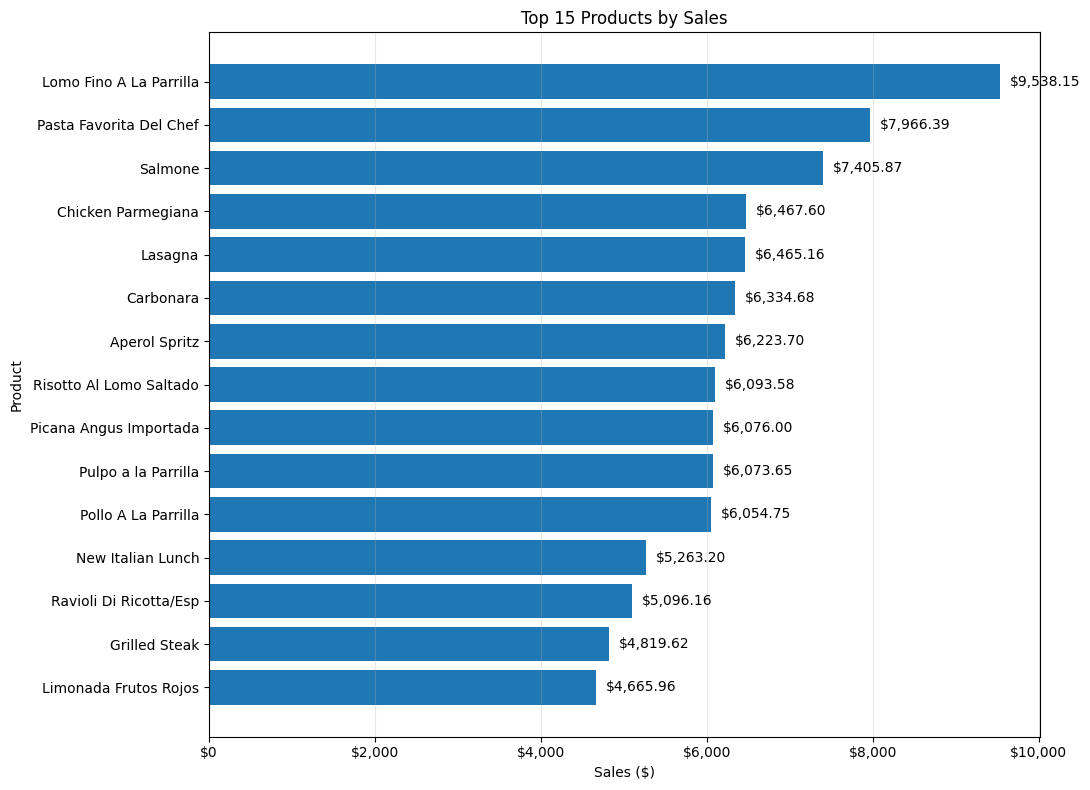

In [6]:
# Create a horizontal bar chart for the fifteen products with the highest sales

top_product_sales = product_sales.head(15)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_product_sales["Product"],
    top_product_sales["Sales"]
)

plt.title("Top 15 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")

# Display the highest-selling product at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add sales labels at the end of each bar
for bar, value in zip(
    bars,
    top_product_sales["Sales"]
):
    plt.text(
        value + 120,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`Lomo Fino A La Parrilla` was the highest-selling product during the January–March 2026 period, generating $9,538.15 in total sales.

`Pasta Favorita Del Chef` and `Salmone` followed with $7,966.39 and $7,405.87, respectively, while several pasta and grilled protein dishes also ranked among the strongest revenue contributors.

The Top 15 includes products from different menu categories, indicating that high sales performance is not concentrated in a single type of item.

`Limonada Frutos Rojos` stands out because it entered the Top 15 by sales while recording a substantially higher quantity sold than most other products in the ranking, suggesting a lower average sales value per unit compared with higher-priced dishes.

## Pareto Analysis

This section evaluates the concentration of product sales by calculating the cumulative contribution of products ranked from highest to lowest sales.

The analysis helps determine how many products are required to generate approximately 80% of total product revenue during the January–March 2026 period.

In [7]:
# Calculate cumulative product sales and cumulative sales contribution

pareto_products = product_sales.copy()

pareto_products["Cumulative Sales"] = pareto_products["Sales"].cumsum()

pareto_products["Cumulative Sales (%)"] = (
    pareto_products["Cumulative Sales"] / pareto_products["Sales"].sum()
) * 100

pareto_products.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}",
    "Cumulative Sales": "${:,.2f}",
    "Cumulative Sales (%)": "{:.2f}%"
})

,Product,Sales,Quantity,Cumulative Sales,Cumulative Sales (%)
0,Lomo Fino A La Parrilla,"$9,538.15",458.00,"$9,538.15",3.10%
1,Pasta Favorita Del Chef,"$7,966.39",383.00,"$17,504.54",5.69%
2,Salmone,"$7,405.87",320.00,"$24,910.41",8.10%
3,Chicken Parmegiana,"$6,467.60",426.50,"$31,378.01",10.21%
4,Lasagna,"$6,465.16",470.00,"$37,843.17",12.31%
5,Carbonara,"$6,334.68",492.00,"$44,177.85",14.37%
6,Aperol Spritz,"$6,223.70",524.00,"$50,401.55",16.40%
7,Risotto Al Lomo Saltado,"$6,093.58",262.00,"$56,495.13",18.38%
8,Picana Angus Importada,"$6,076.00",219.00,"$62,571.13",20.36%
9,Pulpo a la Parrilla,"$6,073.65",422.00,"$68,644.78",22.33%


In [8]:
# Identify the number of products required to reach at least 80% of total sales

products_to_80 = (
    pareto_products["Cumulative Sales (%)"] < 80
).sum() + 1

sales_share_80 = pareto_products.loc[
    products_to_80 - 1,
    "Cumulative Sales (%)"
]

product_share_80 = (
    products_to_80 / len(pareto_products)
) * 100

print(f"Products required to reach at least 80% of sales: {products_to_80}")
print(f"Share of total products: {product_share_80:.2f}%")
print(f"Cumulative sales contribution: {sales_share_80:.2f}%")

Products required to reach at least 80% of sales: 70
Share of total products: 20.47%
Cumulative sales contribution: 80.16%


### Pareto Analysis Visualization

The following Pareto chart shows product sales ranked from highest to lowest together with the cumulative percentage of total sales. The 80% reference line helps identify the group of products responsible for most revenue.

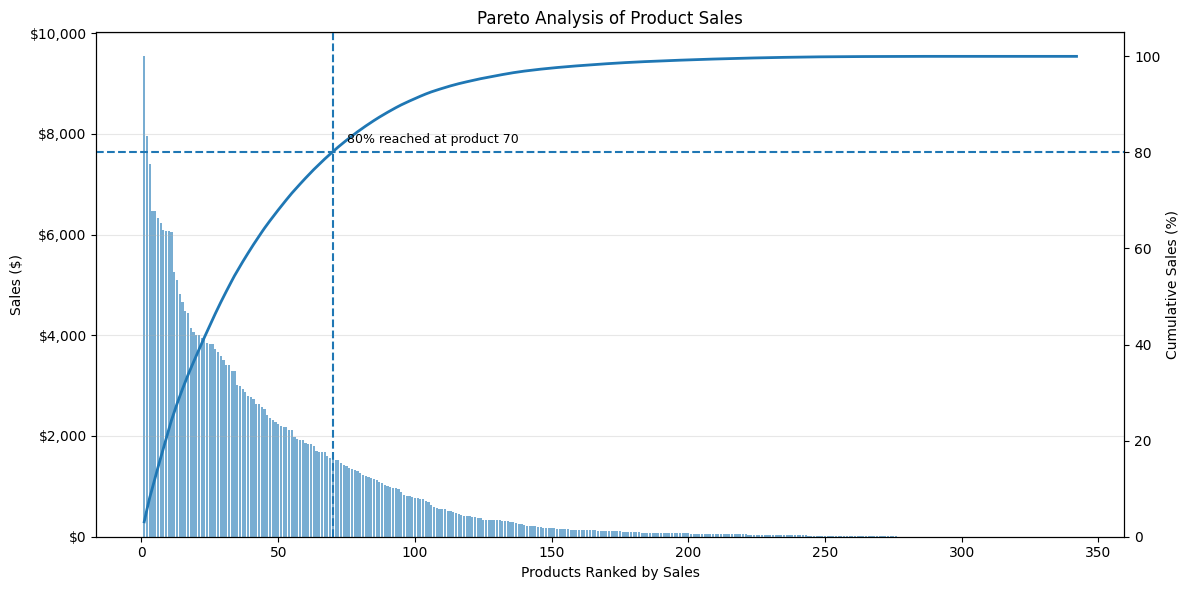

In [9]:
# Create a Pareto chart for product sales

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(1, len(pareto_products) + 1)

# Plot individual product sales
ax1.bar(
    x,
    pareto_products["Sales"],
    alpha=0.6
)

ax1.set_title("Pareto Analysis of Product Sales")
ax1.set_xlabel("Products Ranked by Sales")
ax1.set_ylabel("Sales ($)")

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Create a second axis for cumulative sales percentage
ax2 = ax1.twinx()

ax2.plot(
    x,
    pareto_products["Cumulative Sales (%)"],
    linewidth=2
)

ax2.set_ylabel("Cumulative Sales (%)")
ax2.set_ylim(0, 105)

ax2.text(
    products_to_80 + 5,
    82,
    f"80% reached at product {products_to_80}",
    fontsize=9
)

# Add the 80% reference line
ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5
)

# Mark the product where cumulative sales reach 80%
ax2.axvline(
    x=products_to_80,
    linestyle="--",
    linewidth=1.5
)

ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The Pareto analysis shows that 70 products, representing 20.47% of the total product portfolio, generated approximately 80.16% of total sales during the January–March 2026 period.

This closely follows the 80/20 principle, indicating that a relatively small group of products is responsible for the majority of revenue.

The result highlights the commercial importance of this core product group and suggests that inventory availability, pricing, menu visibility, and promotional decisions should give particular attention to these high-impact products.

## Product Sales Treemap

This section provides a visual representation of the leading products based on total sales during the January–March 2026 period.

The treemap focuses on the Top 20 products by sales, with the size of each rectangle representing the relative revenue contribution of each product.

### Product Sales Treemap Visualization

The following treemap highlights the twenty products with the highest total sales. Larger rectangles represent products with greater revenue contribution.

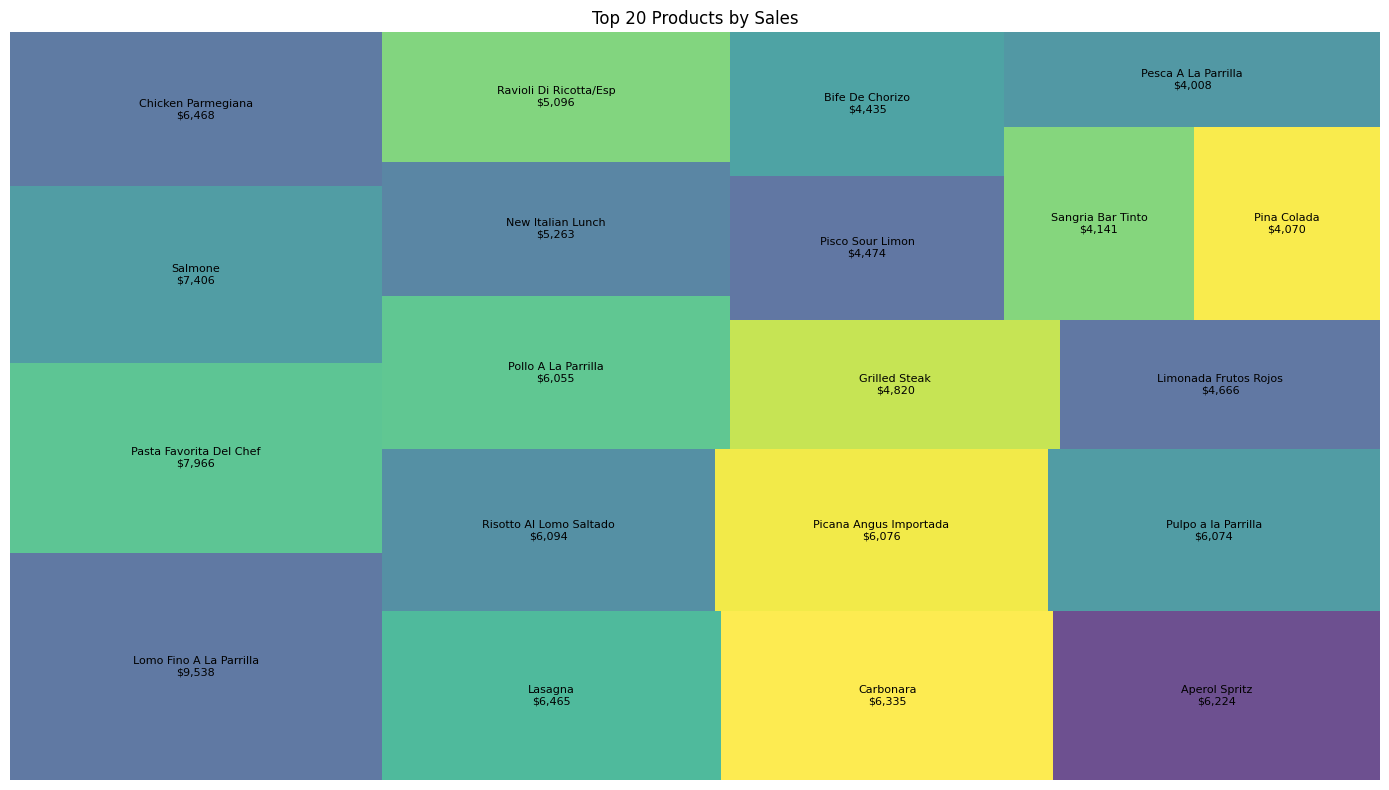

In [10]:
# Create a treemap for the twenty products with the highest total sales

top_20_treemap = product_sales.head(20).copy()

labels = [
    f"{product}\n${sales:,.0f}"
    for product, sales in zip(
        top_20_treemap["Product"],
        top_20_treemap["Sales"]
    )
]

plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=top_20_treemap["Sales"],
    label=labels,
    alpha=0.8,
    text_kwargs={"fontsize": 8}
)

plt.title("Top 20 Products by Sales")
plt.axis("off")

plt.tight_layout()
plt.show()

### Key Insight

The treemap shows that the leading products contribute meaningfully to total revenue, although no single product overwhelmingly dominates the Top 20.

`Lomo Fino A La Parrilla` occupies the largest area, confirming its position as the highest-selling product during the January–March 2026 period.

The distribution across several relatively large rectangles indicates that revenue among the Top 20 products is shared across multiple menu items rather than being concentrated in only one or two products.

The presence of dishes, beverages, and alcoholic drinks among the leading products also reflects a diversified mix of high-performing items.

## Quantity vs Sales Relationship

This section analyzes the relationship between quantity sold and total sales by product during the January–March 2026 period.

The objective is to identify products that combine high sales volume with strong revenue generation, as well as products that stand out because of unusually high quantity or high sales value.

### Quantity vs Sales Visualization

The following scatter plot compares quantity sold with total sales for each product. Selected high-impact products are labeled to highlight the most relevant patterns.

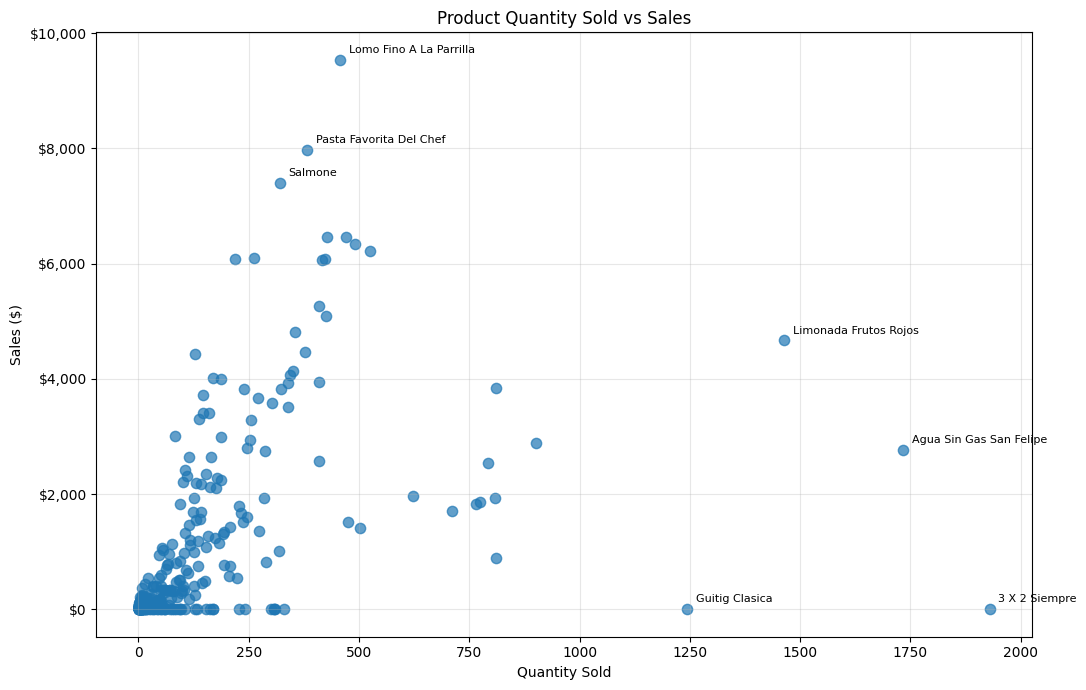

In [11]:
# Create a scatter plot to compare quantity sold with total sales by product

plt.figure(figsize=(11, 7))

plt.scatter(
    product_sales["Quantity"],
    product_sales["Sales"],
    s=55,
    alpha=0.7
)

# Select only the most relevant products to label

products_to_label = [
    "Lomo Fino A La Parrilla",
    "Pasta Favorita Del Chef",
    "Salmone",
    "Limonada Frutos Rojos",
    "Agua Sin Gas San Felipe",
    "3 X 2 Siempre",
    "Guitig Clasica"
]

selected_products = product_sales[
    product_sales["Product"].isin(products_to_label)
]

for _, row in selected_products.iterrows():
    plt.text(
        row["Quantity"] + 20,
        row["Sales"] + 120,
        row["Product"],
        fontsize=8
    )

plt.title("Product Quantity Sold vs Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The scatter plot shows a clear positive relationship between quantity sold and total sales, although the relationship varies substantially depending on the type and average value of each product.

`Lomo Fino A La Parrilla`, `Pasta Favorita Del Chef`, and `Salmone` stand out as products that generate high revenue without requiring the highest sales volumes, indicating a relatively high monetary value per unit.

`Limonada Frutos Rojos` represents the opposite pattern: it records one of the highest quantities sold while generating a more moderate level of total sales, suggesting a lower average value per unit.

Other high-volume products such as `Agua Sin Gas San Felipe`, `Guitig Clasica`, and `3 X 2 Siempre` further demonstrate that high quantity does not necessarily translate into high revenue.

## Top Products by Quantity Sold

This section identifies the products with the highest total quantity sold during the January–March 2026 period, helping distinguish high-volume items from products that primarily generate revenue through higher unit value.

In [12]:
# Rank products from highest to lowest quantity sold

product_quantity = (
    product_sales
    .sort_values("Quantity", ascending=False)
    .reset_index(drop=True)
)

product_quantity.head(15).style.format({
    "Quantity": "{:,.2f}",
    "Sales": "${:,.2f}"
})

,Product,Sales,Quantity
0,3 X 2 Siempre,$0.00,"1,930.00"
1,Agua Sin Gas San Felipe,"$2,769.56","1,734.00"
2,Limonada Frutos Rojos,"$4,665.96","1,464.00"
3,Guitig Clasica,$0.00,"1,244.00"
4,Guitig,"$2,880.01",902.00
5,Limonada De Mandarina,"$3,840.00",811.00
6,Empaque Delivery,$881.80,811.00
7,Coca Zero 300CC,"$1,925.01",809.00
8,Limonada Con H.B,"$2,540.32",793.00
9,Limonada Imperial,"$1,857.60",775.00


### Top Products by Quantity Sold Visualization

The following horizontal bar chart shows the fifteen products with the highest quantity sold during the January–March 2026 period.

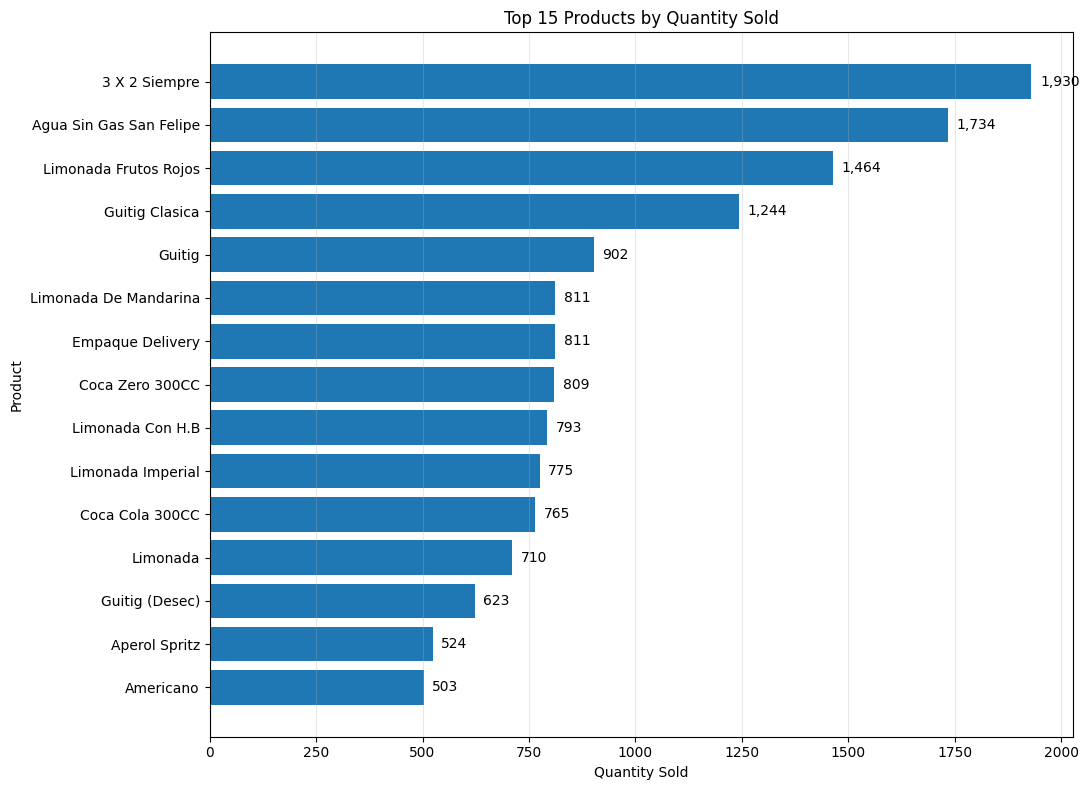

In [13]:
# Create a horizontal bar chart for the fifteen products with the highest quantity sold

top_product_quantity = product_quantity.head(15)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_product_quantity["Product"],
    top_product_quantity["Quantity"]
)

plt.title("Top 15 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

# Display the highest-volume product at the top
plt.gca().invert_yaxis()

# Add quantity labels at the end of each bar
for bar, value in zip(
    bars,
    top_product_quantity["Quantity"]
):
    plt.text(
        value + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The highest-volume products during the January–March 2026 period were dominated by beverages, packaging-related items, and promotional or non-revenue entries rather than by the highest-selling food items.

`3 X 2 Siempre` recorded the highest quantity at 1,930 units, although it generated no direct sales revenue. `Agua Sin Gas San Felipe` and `Limonada Frutos Rojos` followed with 1,734 and 1,464 units, respectively.

The ranking highlights an important distinction between sales volume and revenue contribution: several high-quantity products generate relatively modest sales because of their lower average value per unit.

This reinforces the need to evaluate both quantity and monetary performance when assessing product importance.

## Average Sales Value per Unit

This section calculates the average sales value generated per unit sold for each product during the January–March 2026 period.

The metric helps distinguish products that generate higher revenue per unit from products that depend primarily on high sales volume.

In [14]:
# Calculate the average sales value per unit for each product

product_value = product_sales.copy()

product_value["Average Sales per Unit"] = (
    product_value["Sales"] / product_value["Quantity"]
)

product_value = (
    product_value
    .replace([float("inf"), -float("inf")], pd.NA)
    .dropna(subset=["Average Sales per Unit"])
    .sort_values("Average Sales per Unit", ascending=False)
    .reset_index(drop=True)
)

product_value.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}",
    "Average Sales per Unit": "${:,.2f}"
})

,Product,Sales,Quantity,Average Sales per Unit
0,Chandon Brut Rose,$214.40,4.00,$53.60
1,Chandon Extra Brut,$104.00,2.00,$52.00
2,Undurraga Ribaris Carmenere,$51.20,1.00,$51.20
3,Martin Codax Albariðo,$151.20,3.00,$50.40
4,Novas Gran Reser Org Carmenere,$49.60,1.00,$49.60
5,Navarro Colecc Priv Chardonnay,$47.20,1.00,$47.20
6,N. Correas Colecc Priv Malbec,$141.60,3.00,$47.20
7,Bolla Valpolicella Doc,$43.20,1.00,$43.20
8,Zonin Igt Primitivo Puglia,$127.20,3.00,$42.40
9,Marques De Riscal Tempranillo,$122.40,3.00,$40.80


In [15]:
# Filter products with at least 20 units sold before ranking by average sales value per unit

product_value_filtered = (
    product_value[
        product_value["Quantity"] >= 20
    ]
    .sort_values("Average Sales per Unit", ascending=False)
    .reset_index(drop=True)
)

product_value_filtered.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}",
    "Average Sales per Unit": "${:,.2f}"
})

,Product,Sales,Quantity,Average Sales per Unit
0,Rack De Cordero Importado,"$3,008.00",82.00,$36.68
1,Bife De Chorizo,"$4,435.20",127.00,$34.92
2,Picana Angus Importada,"$6,076.00",219.00,$27.74
3,Risotto Frutti Di Mare,"$3,723.15",146.00,$25.50
4,Asap,$547.80,22.00,$24.90
5,Pasta Frutti Di Mare,"$3,294.27",137.00,$24.05
6,Pesca A La Parrilla,"$4,008.00",169.00,$23.72
7,Risotto Al Lomo Saltado,"$6,093.58",262.00,$23.26
8,Lomo Saltado Huancaina,"$3,410.40",147.00,$23.20
9,Salmone,"$7,405.87",320.00,$23.14


### Average Sales Value per Unit Visualization

The following horizontal bar chart shows the fifteen products with the highest average sales value per unit among products with at least 20 units sold during the January–March 2026 period.

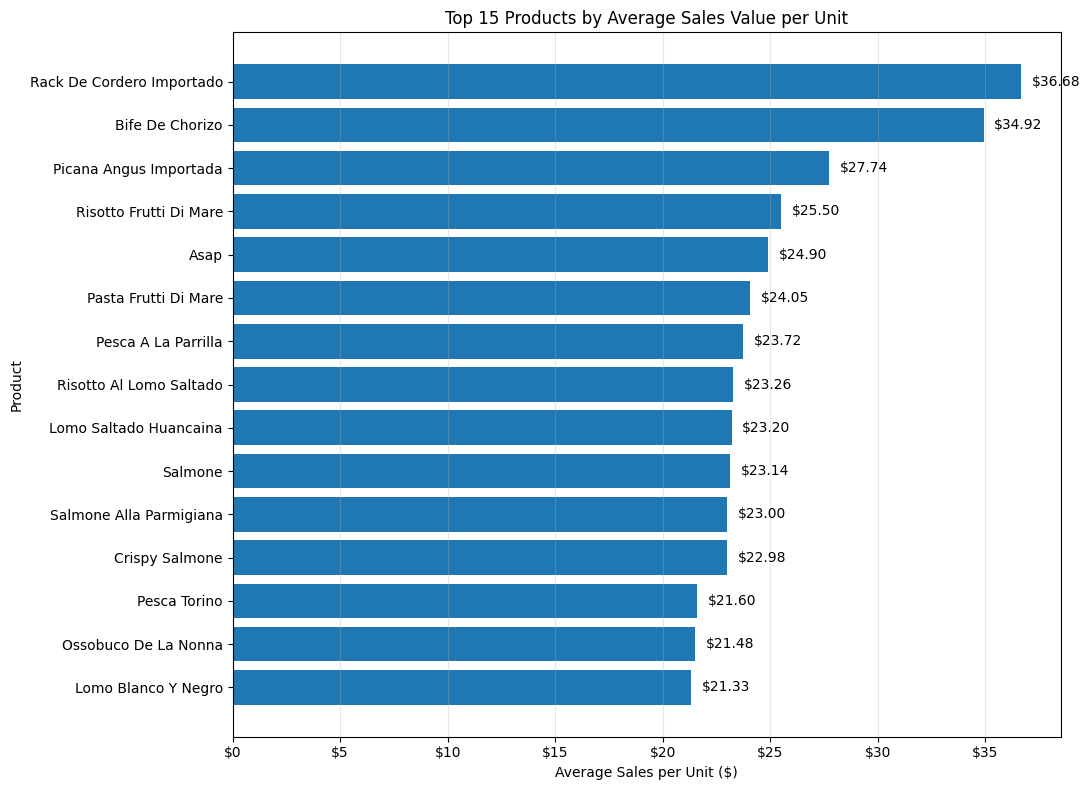

In [16]:
# Create a horizontal bar chart for products with the highest average sales value per unit

top_product_value = product_value_filtered.head(15)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_product_value["Product"],
    top_product_value["Average Sales per Unit"]
)

plt.title("Top 15 Products by Average Sales Value per Unit")
plt.xlabel("Average Sales per Unit ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

for bar, value in zip(
    bars,
    top_product_value["Average Sales per Unit"]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Among products with at least 20 units sold, `Rack De Cordero Importado` generated the highest average sales value per unit at $36.68, followed by `Bife De Chorizo` at $34.92 and `Picana Angus Importada` at $27.74.

The ranking is dominated by higher-priced meat, seafood, and premium dishes, showing that these products generate substantially more revenue per unit than high-volume beverages and lower-priced items.

This metric reflects average sales value per unit rather than profitability. Product costs are not included in the dataset, so higher sales value per unit should not be interpreted as higher profit margin.

## Lowest-Performing Products

This section identifies products with the lowest total sales during the January–March 2026 period, helping highlight items that may require further commercial review.

Low sales alone should not be interpreted as a reason for product removal, since factors such as product availability, seasonality, menu placement, promotional use, or recent introduction are not included in the dataset.

In [17]:
# Rank products from lowest to highest total sales

lowest_product_sales = (
    product_sales
    .sort_values("Sales", ascending=True)
    .reset_index(drop=True)
)

lowest_product_sales.head(20).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}"
})

,Product,Sales,Quantity
0,+ Zumo Limon,$0.00,307.00
1,Sprite 1.35 Lt,$0.00,91.00
2,Sauvignon Blanc,$0.00,2.00
3,Copa Sangiovese,$0.00,152.10
4,Malbec,$0.00,24.00
5,Merlot,$0.00,4.00
6,Coca Cola 1.35 Lt,$0.00,85.00
7,Pasta (Tp),$0.00,228.00
8,Pasta It,$0.00,310.00
9,Chardonnay,$0.00,9.00


### Zero-Revenue Products

Several products recorded quantity activity during the January–March 2026 period but generated no direct sales revenue.

These entries may correspond to complimentary items, bundled products, promotional components, operational items, or other non-revenue transactions. Therefore, they should not be interpreted as low-performing products without additional business context.

In [18]:
# Identify products with quantity activity but zero sales revenue

zero_revenue_products = (
    product_sales[
        (product_sales["Sales"] == 0) &
        (product_sales["Quantity"] > 0)
    ]
    .sort_values("Quantity", ascending=False)
    .reset_index(drop=True)
)

zero_revenue_products.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}"
})

,Product,Sales,Quantity
0,3 X 2 Siempre,$0.00,"1,930.00"
1,Guitig Clasica,$0.00,"1,244.00"
2,Aderezo Italiano,$0.00,329.60
3,Pasta It,$0.00,310.00
4,Lasagna Carne,$0.00,307.00
5,+ Zumo Limon,$0.00,307.00
6,Toallitas Expansibles,$0.00,301.00
7,Opcion A,$0.00,241.00
8,Pasta (Tp),$0.00,228.00
9,Aderezo Honey Mustar,$0.00,169.00


### Lowest-Selling Revenue-Generating Products

To identify commercially low-performing products more meaningfully, products with zero sales revenue are excluded from the following ranking.

In [19]:
# Rank revenue-generating products from lowest to highest sales

lowest_revenue_products = (
    product_sales[
        product_sales["Sales"] > 0
    ]
    .sort_values("Sales", ascending=True)
    .reset_index(drop=True)
)

lowest_revenue_products.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}"
})

,Product,Sales,Quantity
0,Extra Pimientos Verdes,$1.50,1.00
1,Extra Aderezo Caesar,$2.50,1.00
2,Extra Aderezo Honey Mustard,$2.50,1.00
3,Extra Choclito Dulce,$3.00,2.00
4,Agua Tonica,$3.00,2.00
5,Extra Cherry Confitado,$3.09,1.00
6,Extra Tomate Cherry Fresco,$3.98,2.00
7,Extra Huevo,$3.98,2.00
8,Extra Salsa Pesto,$4.19,1.00
9,Extra Queso Gruyere,$4.19,1.00


In [20]:
# Aggregate product performance while preserving product category

product_review = (
    df.groupby(["Category", "Product"], as_index=False)
    .agg({
        "Quantity": "sum",
        "Sales": "sum"
    })
    .sort_values("Sales", ascending=True)
    .reset_index(drop=True)
)

product_review.head(30).style.format({
    "Quantity": "{:,.2f}",
    "Sales": "${:,.2f}"
})

,Category,Product,Quantity,Sales
0,Wine,Sauvignon Blanc,2.00,$0.00
1,Wine,Copa Sangiovese,152.10,$0.00
2,Wine,Copa Trebbiano,96.50,$0.00
3,Wine,Copa Marques De Riscal,94.00,$0.00
4,Wine,Copa Salentein Malbec,131.60,$0.00
5,Coffee & Tea,Premium Tea,57.00,$0.00
6,Dessert,Tentazione Di Cacao (Pc),127.00,$0.00
7,Water,+ Zumo Limon,307.00,$0.00
8,Coffee & Tea,Te De La Casa (Hdt),7.00,$0.00
9,Extras,Arroz (G),18.00,$0.00


In [21]:
# Display the available product categories

sorted(df["Category"].dropna().unique())

['3x2 Promotion',
 'Beer',
 'Children',
 'Coffee & Tea',
 'Dessert',
 'Entrees',
 'Events Menus',
 'Extras',
 'Italian Lunch',
 'Juice',
 'Liquor',
 'Meat, chicken & seafood',
 'Pasta',
 'Pizza & Calzone',
 'Pop Beverages',
 'Risotto',
 'Salads',
 'Soups',
 'Specials',
 'Water',
 'Wine']

### Commercial Product Review Candidates

To identify more meaningful candidates for commercial review, auxiliary categories such as promotions, extras, and event-menu components are excluded.

The following analysis focuses on revenue-generating menu products with comparatively low performance in both total sales and quantity sold.

In [22]:
# Exclude auxiliary categories that do not represent standalone commercial products

excluded_categories = [
    "3x2 Promotion",
    "Extras",
    "Events Menus"
]

commercial_products = (
    product_review[
        (~product_review["Category"].isin(excluded_categories)) &
        (product_review["Sales"] > 0) &
        (product_review["Quantity"] > 0)
    ]
    .copy()
)

print(f"Commercial products analyzed: {len(commercial_products)}")

Commercial products analyzed: 220


In [23]:
# Calculate the lower quartile thresholds for sales and quantity

sales_q25 = commercial_products["Sales"].quantile(0.25)
quantity_q25 = commercial_products["Quantity"].quantile(0.25)

print(f"25th percentile - Sales: ${sales_q25:,.2f}")
print(f"25th percentile - Quantity: {quantity_q25:,.2f}")

25th percentile - Sales: $59.39
25th percentile - Quantity: 4.00


In [24]:
# Identify products in the bottom quartile for both sales and quantity

review_candidates = (
    commercial_products[
        (commercial_products["Sales"] <= sales_q25) &
        (commercial_products["Quantity"] <= quantity_q25)
    ]
    .sort_values(["Sales", "Quantity"], ascending=True)
    .reset_index(drop=True)
)

review_candidates.head(15).style.format({
    "Sales": "${:,.2f}",
    "Quantity": "{:,.2f}"
})

,Category,Product,Quantity,Sales
0,Water,Agua Tonica,2.00,$3.00
1,Juice,Jugo Naranja / Frutilla Ninos,2.00,$6.40
2,Coffee & Tea,Cioccolata,3.00,$7.20
3,Juice,Batido De Fruta,2.00,$7.80
4,Liquor,Ron Viejo De Caldas,1.00,$8.00
5,Liquor,Baileys,1.00,$8.00
6,Dessert,Torta De Chocolate (Il),3.00,$8.97
7,Liquor,Gin Beefeater,1.00,$9.00
8,Juice,Jugo Guanabana / Mora Ninos,3.00,$9.60
9,Juice,Jugo Pina,3.00,$9.82


### Commercial Product Review Candidates Visualization

The following chart shows the fifteen lowest-selling products among the commercial review candidates identified through the bottom-quartile criteria for both sales and quantity sold.

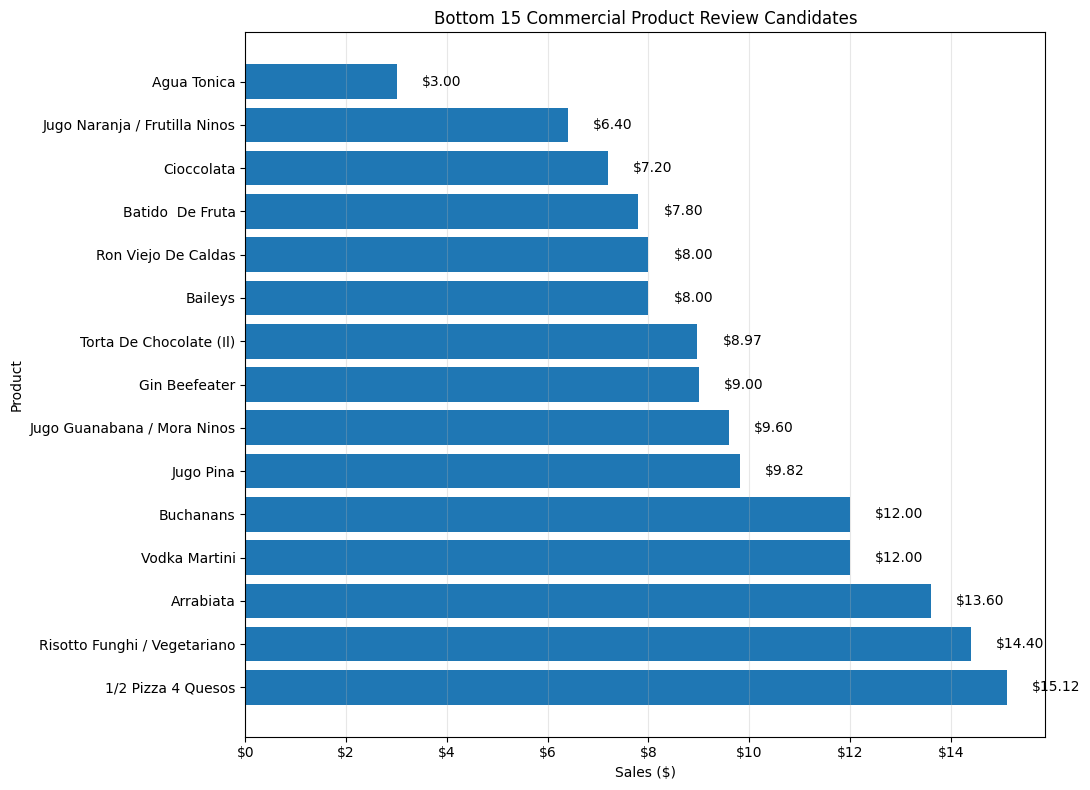

In [25]:
# Visualize the fifteen lowest-selling commercial review candidates

bottom_15_review = review_candidates.head(15)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    bottom_15_review["Product"],
    bottom_15_review["Sales"]
)

plt.title("Bottom 15 Commercial Product Review Candidates")
plt.xlabel("Sales ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

for bar, value in zip(
    bars,
    bottom_15_review["Sales"]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

After excluding auxiliary categories and zero-revenue entries, 220 revenue-generating commercial products were evaluated for potential review.

Products were considered review candidates when they fell within the bottom quartile for both sales and quantity sold. The resulting thresholds were $59.39 in total sales and 4 units sold during the January–March 2026 period.

The resulting group includes products from several categories, such as beverages, liquor, desserts, pasta, risotto, and pizza, indicating that low commercial activity is not limited to a single menu category.

Items such as `Arrabiata`, `Risotto Funghi / Vegetariano`, and `1/2 Pizza 4 Quesos` recorded particularly low sales volume and revenue during the analyzed period and may warrant further commercial review.

However, these products should be considered candidates for review rather than automatic removal. Additional information such as profitability, ingredient costs, product availability, menu tenure, seasonality, and strategic importance would be required before making a final menu decision.

## Product Sales Analysis Summary

The product sales analysis covers the January–March 2026 period and includes 342 unique products.

During the analyzed period, products generated $307,367.07 in total sales and 42,704.57 units sold.

`Lomo Fino A La Parrilla` was the highest-selling product, generating $9,538.15 in total sales, followed by `Pasta Favorita Del Chef` and `Salmone`.

The Pareto analysis showed that 70 products, representing 20.47% of the product portfolio, generated approximately 80.16% of total sales. This indicates a strong concentration of revenue among a relatively small group of products.

The quantity analysis showed that high sales volume does not always translate into high revenue. Several beverages and promotional or non-revenue items recorded high quantities, while premium dishes generated substantially higher sales value per unit.

Among products with at least 20 units sold, `Rack De Cordero Importado` recorded the highest average sales value per unit at $36.68.

The commercial review analysis identified products with low performance in both sales and quantity after excluding auxiliary categories and zero-revenue entries. These products should be treated as candidates for further review rather than automatic removal, since profitability, costs, seasonality, availability, and strategic importance are not included in the dataset.

Overall, the analysis shows that product performance varies significantly across the menu and that evaluating sales, quantity, revenue concentration, and average value per unit together provides a more complete view of product contribution.

---

## Author

**Guido Acosta**

Data Analyst Portfolio Project

GitHub Portfolio – 2026